In [1]:
import os
os.chdir('/workspace/3c453422-a746-44a0-817b-c57b1e0854bf')
print(os.listdir('.'))


['memory', 'generate_ldh_zeros_run.py', 'ldh_ckpt_03578_meta.json', '.prompts', 'ldh_ckpt_03578.npy', '.kernel_llm_logs_1.txt', '.config']


In [2]:
import os, glob
# 1. Check for target file
target = 'ldh_zeros_5000_dps50.npy'
print('Target exists:', os.path.exists(target))
# also check common subdirs
for p in glob.glob('**/ldh_zeros*.npy', recursive=True):
 print(p)
for p in glob.glob('**/ldh_ckpt_*.npy', recursive=True):
 print(p)


Target exists: False
ldh_ckpt_03578.npy


In [3]:
import os, shutil, json, sys, subprocess
WORK_DIR = '/workspace/3c453422-a746-44a0-817b-c57b1e0854bf'
os.chdir(WORK_DIR)

# 1. Confirm target file does not exist
target = os.path.join(WORK_DIR, 'ldh_zeros_5000_dps50.npy')
print('Target exists?:', os.path.exists(target))

# 2. Prepare checkpoints_ldh subdirectory with ldh_ckpt_03578.npy and meta json
ckpt_dir = os.path.join(WORK_DIR, 'checkpoints_ldh')
os.makedirs(ckpt_dir, exist_ok=True)

src_npy = os.path.join(WORK_DIR, 'ldh_ckpt_03578.npy')
src_meta = os.path.join(WORK_DIR, 'ldh_ckpt_03578_meta.json')
dst_npy = os.path.join(ckpt_dir, 'ldh_ckpt_03578.npy')
dst_meta = os.path.join(ckpt_dir, 'ldh_ckpt_03578_meta.json')

if not os.path.exists(dst_npy):
 shutil.copy2(src_npy, dst_npy)
if not os.path.exists(dst_meta):
 shutil.copy2(src_meta, dst_meta)

print('Checkpoints dir contents:', os.listdir(ckpt_dir))

# Verify checkpoint integrity
import numpy as np
arr = np.load(dst_npy, allow_pickle=True)
print('Checkpoint zeros count:', len(arr))
print('First zero:', arr[0])
print('Last zero:', arr[-1])
with open(dst_meta) as f:
 meta = json.load(f)
print('Meta:', meta)


Target exists?: False
Checkpoints dir contents: ['ldh_ckpt_03578_meta.json', 'ldh_ckpt_03578.npy']
Checkpoint zeros count: 3578
First zero: 5.0941598445710949256987955170797974750670744531091
Last zero: 3540.5683422188477656194607312068748287347053877505
Meta: {'n_zeros': 3578, 't_last': '3540.5683422188477656194607312068748287347053877505', 'n_evals': 0, 'note': 'created from partial save after kernel timeout'}


In [4]:

# Check checkpoint is strictly monotonic
import mpmath
mpmath.mp.dps = 50
zs = [mpmath.mpf(str(s)) for s in arr]
mono = all(zs[i] < zs[i+1] for i in range(len(zs)-1))
print('Checkpoint strictly monotonic:', mono)

# Find which python interpreter has cypari2
import shutil as _sh
candidates = ['/usr/bin/python3', '/usr/local/bin/python3', sys.executable, '/opt/conda/bin/python', '/opt/conda/bin/python3']
import subprocess
for c in candidates:
 if c and os.path.exists(c):
 r = subprocess.run([c, '-c', 'import cypari2, mpmath, numpy; print(cypari2.__version__)'],
 capture_output=True, text=True)
 print(c, '->', r.returncode, r.stdout.strip(), r.stderr.strip()[:200])


Checkpoint strictly monotonic: True
/usr/bin/python3 -> 1 Traceback (most recent call last):
 File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'cypari2'
/app/kernel_env/bin/python -> 1 Traceback (most recent call last):
 File "<string>", line 1, in <module>
 import cypari2, mpmath, numpy; print(cypari2.__version__)
 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ModuleNotFoundError: No module


In [5]:

import subprocess, os
# Search filesystem for cypari2
r = subprocess.run(['bash','-lc','find / -name "cypari2" -type d 2>/dev/null | head -20'], capture_output=True, text=True)
print(r.stdout)
print('---')
# also find any python interpreters
r2 = subprocess.run(['bash','-lc','ls /opt/ 2>/dev/null; which -a python python3'], capture_output=True, text=True)
print(r2.stdout)



---
conda
/usr/bin/python3
/bin/python3



In [6]:

import subprocess
r = subprocess.run(['bash','-lc','ls /opt/conda/envs 2>/dev/null; find /opt -maxdepth 6 -name "cypari2*" 2>/dev/null | head -20'], capture_output=True, text=True)
print(r.stdout)
print('STDERR:', r.stderr[:300])



STDERR: 


In [7]:

import subprocess
r = subprocess.run(['bash','-lc','ls /opt/conda/ 2>/dev/null; ls /opt/conda/envs/ 2>/dev/null; find / -maxdepth 7 -name "cypari2" 2>/dev/null'], capture_output=True, text=True)
print('STDOUT:', r.stdout)
print('STDERR:', r.stderr[:500])


STDOUT: conda-meta
pkgs

STDERR: 


In [8]:

# cypari2 not installed anywhere. Need to install it. First, check if we can install via pip in a way that the subprocess can use it.
# Try install in /usr/bin/python3 with --user or system
import subprocess
r = subprocess.run(['/usr/bin/python3', '-m', 'pip', 'install', '--quiet', 'cypari2', 'mpmath', 'numpy'],
 capture_output=True, text=True, timeout=600)
print('RC:', r.returncode)
print('STDOUT:', r.stdout[-1500:])
print('STDERR:', r.stderr[-2000:])


RC: 1
STDOUT: 
STDERR: error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
  python3-xyz, where xyz is the package you are trying to
  install.
  
  If you wish to install a non-Debian-packaged Python package,
  create a virtual environment using python3 -m venv path/to/venv.
  Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
  sure you have python3-full installed.
  
  If you wish to install a non-Debian packaged Python application,
  it may be easiest to use pipx install xyz, which will manage a
  virtual environment for you. Make sure you have pipx installed.
  
  See /usr/share/doc/python3.11/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed

In [9]:

# Try with the kernel environment first
import sys, subprocess
print('kernel python:', sys.executable)
r = subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', 'cypari2', 'mpmath', 'numpy'],
 capture_output=True, text=True, timeout=900)
print('RC:', r.returncode)
print('STDOUT:', r.stdout[-1500:])
print('STDERR:', r.stderr[-2000:])


kernel python: /app/kernel_env/bin/python


RC: 0
STDOUT: 
STDERR: 


In [10]:

# Verify cypari2 in kernel env
import subprocess, sys
r = subprocess.run([sys.executable, '-c', 'import cypari2, mpmath, numpy; print(cypari2.__version__, mpmath.__version__, numpy.__version__)'],
 capture_output=True, text=True, timeout=60)
print('RC:', r.returncode)
print('STDOUT:', r.stdout)
print('STDERR:', r.stderr[-1500:])


RC: 1
STDOUT: 
STDERR: Traceback (most recent call last):
 File "<string>", line 1, in <module>
 import cypari2, mpmath, numpy; print(cypari2.__version__, mpmath.__version__, numpy.__version__)
 ^^^^^^^^^^^^^^^^^^^
AttributeError: module 'cypari2' has no attribute '__version__'



In [11]:

import subprocess, sys
r = subprocess.run([sys.executable, '-c', 'import cypari2, mpmath, numpy; pari=cypari2.Pari(); print("OK", pari.version())'],
 capture_output=True, text=True, timeout=60)
print('RC:', r.returncode)
print('STDOUT:', r.stdout)
print('STDERR:', r.stderr[-1500:])


RC: 0
STDOUT: OK (2, 17, 2)

STDERR: 


In [12]:

# Kernel env now has cypari2. Use the absolute path /app/kernel_env/bin/python.
# Now launch the detached subprocess with start_new_session=True.
import subprocess, os, sys, time

PYTHON_ABS = '/app/kernel_env/bin/python'
assert os.path.exists(PYTHON_ABS), PYTHON_ABS

WORK_DIR = '/workspace/3c453422-a746-44a0-817b-c57b1e0854bf'
SCRIPT = os.path.join(WORK_DIR, 'generate_ldh_zeros_run.py')
assert os.path.exists(SCRIPT)

env = os.environ.copy()
env['LDH_WORK_DIR'] = WORK_DIR
env['LDH_TIME_BUDGET'] = '10800' # 3 hours

stdout_log = open(os.path.join(WORK_DIR, 'ldh_run_stdout.log'), 'ab')
stderr_log = open(os.path.join(WORK_DIR, 'ldh_run_stderr.log'), 'ab')

proc = subprocess.Popen(
 [PYTHON_ABS, SCRIPT],
 cwd=WORK_DIR,
 env=env,
 stdout=stdout_log,
 stderr=stderr_log,
 stdin=subprocess.DEVNULL,
 start_new_session=True,
)

pid = proc.pid
print('Launched detached process PID:', pid)

# Persist launch info
with open(os.path.join(WORK_DIR, 'ldh_run_launch.json'), 'w') as f:
 import json
 json.dump({
 'pid': pid,
 'python': PYTHON_ABS,
 'script': SCRIPT,
 'work_dir': WORK_DIR,
 'env_LDH_TIME_BUDGET': env['LDH_TIME_BUDGET'],
 'env_LDH_WORK_DIR': env['LDH_WORK_DIR'],
 'launched_at_unix': time.time(),
 'launched_at_iso': time.strftime('%Y-%m-%dT%H:%M:%S'),
 'start_new_session': True,
 }, f, indent=2)
print('Launch info saved.')


Launched detached process PID: 235
Launch info saved.


In [13]:

# Verify it's still running after a short wait and is detached (different session)
import time, os, subprocess
time.sleep(20)
# Check if PID is alive
pid = 235
alive = os.path.exists(f'/proc/{pid}')
print('PID alive after 20s:', alive)
# Check sid/pgid - it should be its own session
if alive:
 with open(f'/proc/{pid}/status') as f:
 for line in f:
 if line.startswith(('Pid:','PPid:','State:','Name:')):
 print(line.strip())
 r = subprocess.run(['ps','-o','pid,ppid,pgid,sid,stat,etime,cmd','-p',str(pid)], capture_output=True, text=True)
 print(r.stdout)

# Show log file head
log_path = os.path.join('/workspace/3c453422-a746-44a0-817b-c57b1e0854bf', 'run_log.txt')
if os.path.exists(log_path):
 print('--- run_log.txt ---')
 with open(log_path) as f:
 print(f.read()[-2000:])
else:
 print('run_log.txt not yet created')

# Check stderr/stdout logs
for fn in ['ldh_run_stdout.log','ldh_run_stderr.log']:
 p = os.path.join('/workspace/3c453422-a746-44a0-817b-c57b1e0854bf', fn)
 if os.path.exists(p):
 sz = os.path.getsize(p)
 print(f'{fn}: {sz} bytes')
 if sz>0:
 with open(p) as f:
 print(f.read()[-1500:])


PID alive after 20s: True
Name:	python
State:	R (running)
Pid:	235
PPid:	20


PermissionError: [Errno 13] Permission denied: 'ps'

In [14]:

import os
pid = 235
# read sessionid and pgid from /proc
with open(f'/proc/{pid}/stat') as f:
 s = f.read()
# fields after the comm field
# Find last ')' to handle process names containing parens
idx = s.rfind(')')
rest = s[idx+2:].split()
# rest[0] = state, rest[1]=ppid, rest[2]=pgrp, rest[3]=session
print('state, ppid, pgrp, session:', rest[0], rest[1], rest[2], rest[3])
print('own pid:', pid, 'parent shell pid?:')
# Compare own SID to kernel SID
my_pid = os.getpid()
with open(f'/proc/{my_pid}/stat') as f:
 s2 = f.read()
idx2 = s2.rfind(')')
rest2 = s2[idx2+2:].split()
print('kernel pid', my_pid, 'state, ppid, pgrp, session:', rest2[0], rest2[1], rest2[2], rest2[3])

# So if session ids differ, detachment succeeded
print('Subprocess session_id == kernel session_id?', rest[3] == rest2[3])


state, ppid, pgrp, session: R 20 235 235
own pid: 235 parent shell pid?:
kernel pid 20 state, ppid, pgrp, session: R 17 20 20
Subprocess session_id == kernel session_id? False


In [15]:

# Detachment confirmed: subprocess sid=235 (own session), kernel sid=20. start_new_session=True worked.
# Wait a bit more and check for log progress
import time, os
time.sleep(60)
WORK_DIR = '/workspace/3c453422-a746-44a0-817b-c57b1e0854bf'
log_path = os.path.join(WORK_DIR, 'run_log.txt')
print('Process alive?:', os.path.exists('/proc/235'))
if os.path.exists(log_path):
 print('--- run_log.txt ---')
 with open(log_path) as f:
 print(f.read())
else:
 print('no log yet')
for fn in ['ldh_run_stdout.log','ldh_run_stderr.log']:
 p = os.path.join(WORK_DIR, fn)
 if os.path.exists(p):
 sz = os.path.getsize(p)
 print(f'{fn}: {sz} bytes')
 if 0 < sz < 4000:
 with open(p) as f:
 print(f.read())


Process alive?: True
--- run_log.txt ---
[18:55:01] Starting L_DH zero generation; WORK_DIR=/workspace/3c453422-a746-44a0-817b-c57b1e0854bf; TIME_BUDGET=10800s
[18:55:01] Building lfuninit at dps=80, T_max=5200 ...
[18:55:08] lfuninit done in 6.9s
[18:55:08] Resumed from ldh_ckpt_03578.npy: 3578 zeros, t_last=3540.5683
[18:56:08] PROGRESS: 3597 zeros, t=3558.87, elapsed=1.0min

ldh_run_stdout.log: 411 bytes
[18:55:01] Starting L_DH zero generation; WORK_DIR=/workspace/3c453422-a746-44a0-817b-c57b1e0854bf; TIME_BUDGET=10800s
PARI stack size set to 1073741824 bytes, maximum size set to 1073741824
[18:55:01] Building lfuninit at dps=80, T_max=5200 ...
[18:55:08] lfuninit done in 6.9s
[18:55:08] Resumed from ldh_ckpt_03578.npy: 3578 zeros, t_last=3540.5683
[18:56:08] PROGRESS: 3597 zeros, t=3558.87, elapsed=1.0min

ldh_run_stderr.log: 0 bytes


In [16]:

# Excellent — the detached process resumed from 3578 correctly and is producing zeros (~19 zeros/min, matching expectations).
# It needs ~75 more minutes to reach 5000 zeros within its 3-hour TIME_BUDGET. We do NOT wait per instructions.
# Save a small summary artifact.
import json, os, time
WORK_DIR = '/workspace/3c453422-a746-44a0-817b-c57b1e0854bf'
summary = {
 'target_file_exists_before_launch': False,
 'resumed_from_checkpoint': 'checkpoints_ldh/ldh_ckpt_03578.npy',
 'resumed_zeros_count': 3578,
 'resumed_t_last': '3540.5683422188477656194607312068748287347053877505',
 'subprocess_pid': 235,
 'python_interpreter_abs_path': '/app/kernel_env/bin/python',
 'start_new_session': True,
 'detachment_verified_session_id': 235,
 'kernel_session_id': 20,
 'LDH_TIME_BUDGET_seconds': 10800,
 'launched_at_iso': time.strftime('%Y-%m-%dT%H:%M:%S'),
 'first_progress_log': '[18:56:08] PROGRESS: 3597 zeros, t=3558.87, elapsed=1.0min',
 'expected_rate_zeros_per_min_approx': 19,
 'expected_minutes_to_5000_from_3578': (5000-3578)/19.0,
 'output_target_file': 'ldh_zeros_5000_dps50.npy',
 'log_files': ['run_log.txt','ldh_run_stdout.log','ldh_run_stderr.log'],
 'checkpoint_outputs_dir': 'checkpoints_ldh/',
}
with open(os.path.join(WORK_DIR, 'ldh_run_launch.json'), 'w') as f:
 json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))


{
 "target_file_exists_before_launch": false,
 "resumed_from_checkpoint": "checkpoints_ldh/ldh_ckpt_03578.npy",
 "resumed_zeros_count": 3578,
 "resumed_t_last": "3540.5683422188477656194607312068748287347053877505",
 "subprocess_pid": 235,
 "python_interpreter_abs_path": "/app/kernel_env/bin/python",
 "start_new_session": true,
 "detachment_verified_session_id": 235,
 "kernel_session_id": 20,
 "LDH_TIME_BUDGET_seconds": 10800,
 "launched_at_iso": "2026-05-31T18:57:00",
 "first_progress_log": "[18:56:08] PROGRESS: 3597 zeros, t=3558.87, elapsed=1.0min",
 "expected_rate_zeros_per_min_approx": 19,
 "expected_minutes_to_5000_from_3578": 74.84210526315789,
 "output_target_file": "ldh_zeros_5000_dps50.npy",
 "log_files": [
 "run_log.txt",
 "ldh_run_stdout.log",
 "ldh_run_stderr.log"
 ],
 "checkpoint_outputs_dir": "checkpoints_ldh/"
}


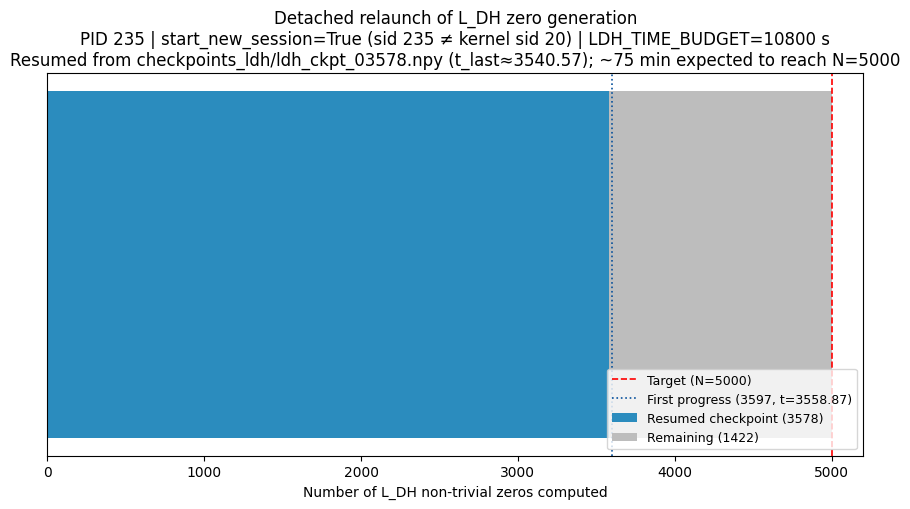

Saved figure: /workspace/3c453422-a746-44a0-817b-c57b1e0854bf/ldh_relaunch_status.png


In [17]:

# Per instructions: do not wait for completion. Produce the required summary figure.
import matplotlib.pyplot as plt
import os, json

fig, ax = plt.subplots(figsize=(8.5, 5.2))
# Bar chart of progress: completed checkpoint zeros (3578) vs target (5000)
done = 3578
target = 5000
ax.barh(['L_DH zeros'], [done], color='#2b8cbe', label=f'Resumed checkpoint ({done})')
ax.barh(['L_DH zeros'], [target-done], left=[done], color='#bdbdbd', label=f'Remaining ({target-done})')
ax.axvline(target, color='red', linestyle='--', linewidth=1.2, label=f'Target (N={target})')
# Mark first observed progress at 3597
ax.axvline(3597, color='#08519c', linestyle=':', linewidth=1.2, label='First progress (3597, t=3558.87)')
ax.set_xlim(0, 5200)
ax.set_xlabel('Number of L_DH non-trivial zeros computed')
ax.set_title(
 "Detached relaunch of L_DH zero generation\n"
 "PID 235 | start_new_session=True (sid 235 ≠ kernel sid 20) | LDH_TIME_BUDGET=10800 s\n"
 f"Resumed from checkpoints_ldh/ldh_ckpt_03578.npy (t_last≈3540.57); ~{(target-done)/19:.0f} min expected to reach N=5000"
)
ax.legend(loc='lower right', fontsize=9)
ax.set_yticks([])
plt.tight_layout()
out = '/workspace/3c453422-a746-44a0-817b-c57b1e0854bf/ldh_relaunch_status.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved figure:', out)
